In [124]:
import rebound
import reboundx
import astropy.constants as constants
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from multiprocess import Pool
import celmech
import scipy.fftpack as fftpack
import os
import glob
from pathlib import Path
import warnings
from joblib import Parallel, delayed
from celmech.miscellaneous import frequency_modified_fourier_transform as fmftc

In [191]:
#helper functions
def findAllIn(data_dir, file_matching, contain_dir=False, save_ls=True, save_name=None):
    if data_dir[-1] != '/':
        data_dir = data_dir + '/'
    if save_name == None:
        save_name = 'all_' + file_matching + '.txt'
    list_files = glob.glob(data_dir + file_matching)
    if not contain_dir:
        list_files[:] = (os.path.basename(i) for i in list_files)
    if save_ls:
        with open(data_dir + save_name, "w") as output:
            for i in list_files:
                output.write(str(i) + '\n')
    return list_files

In [192]:
PATH = '/home/ahekster/reboundx/ipython_examples/runs'

ls = findAllIn(PATH, '*.bin', True, False)

len(ls)

64

In [193]:
def analysis(name):
    sa = rebound.Simulationarchive(name) 
    tmax = sa.tmax
    print("t is:",tmax/1e6, "myr")
    Nsnaps = len(sa)
    interval = int(abs((tmax-sa.tmin)/Nsnaps))
    
    print("Snapshot length is:",interval/1e3, "ky")
    
    Nout = Nsnaps
    n = 8
    
    obl = np.zeros(Nout)
    esinw = np.zeros(Nout)
    e = np.zeros((Nout,n))
    p = np.zeros(Nout)
    pom = np.zeros(Nout)
    incs = np.zeros(Nout)
    els = np.zeros(Nout)
    times = np.zeros(Nout)
    
    omega_star = np.zeros((Nout, n))
    Omega_star = np.zeros((Nout, n))
    
    a = np.zeros((Nout,n))
    z = np.zeros((Nout, n), dtype=complex)
    ζ = np.zeros((Nout, n), dtype=complex)
    
    for i, sim in enumerate(sa):
        sim.move_to_com
        sim.integrator_synchronize()
        qps = sim.particles
        earth = qps['earth']
        time = sim.t
        times[i]=time
    
        sim.integrator_synchronize()
        orbits = sim.orbits()
        
        for j in range(n):
            a[i,j] = orbits[j].a
            z[i,j] = orbits[j].e * np.exp(1j*orbits[j].pomega)
            ζ[i,j] = np.sin(orbits[j].inc/2.) * np.exp(1j*orbits[j].Omega)
            omega_star[i,j] = np.angle(z[i, j])
            Omega_star[i,j] = np.angle(ζ[i, j])
    
    theta_12_vals = np.zeros(len(times))
    j1 = 0
    j2=1
    
    for i in range(len(times)):
        varpi1 = np.angle(z[i, j1])  
        varpi2 = np.angle(z[i, j2])
        Omega1 = np.angle(ζ[i, j1]) 
        Omega2 = np.angle(ζ[i, j2])
        
        theta_12_vals[i] = np.mod((varpi1 - varpi2) + (Omega1 - Omega2), 2*np.pi)
        
    return times, theta_12_vals

In [194]:
%%capture

result = []
for index, name in enumerate(ls):
    result.append(analysis(name))

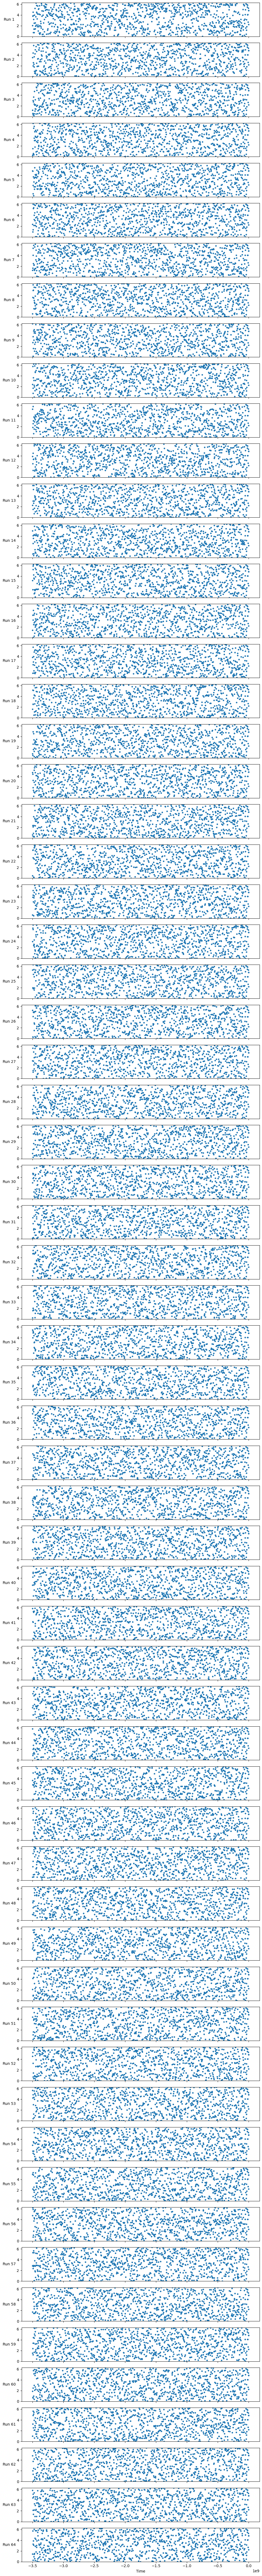

In [195]:
n_runs = len(ls)
fig, axes = plt.subplots(nrows=n_runs, ncols=1, figsize=(10, n_runs*1.5), sharex=True)

for idx, ax in enumerate(axes):
    times_i, theta_i = result[idx]
    ax.plot(times_i, theta_i,'.')
    ax.set_ylim(0, 2 * np.pi)
    ax.set_ylabel(f'Run {idx + 1}', rotation=0, labelpad=20, va='center')

axes[-1].set_xlabel('Time')

plt.tight_layout()
plt.savefig('resonance.png')
plt.show()

In [196]:
es = []

for index, name in enumerate(ls):
    sa = rebound.Simulationarchive(name) 
    tmax = sa.tmax
    Nsnaps = len(sa)
    interval = int(abs((tmax-sa.tmin)/Nsnaps))
        
    Nout = Nsnaps
    n = 8

    e = np.zeros((Nout,n))
 
    times = np.zeros(Nout)
    
    for i, sim in enumerate(sa):
        sim.move_to_com
        sim.integrator_synchronize()
        qps = sim.particles
        earth = qps['earth']
        time = sim.t
        times[i]=time
    
        sim.integrator_synchronize()
        orbits = sim.orbits()
        
        for j in range(n):
            e[i,j] = orbits[j].e
    
    j1 = 0
    
    es.append(e[:,j1])

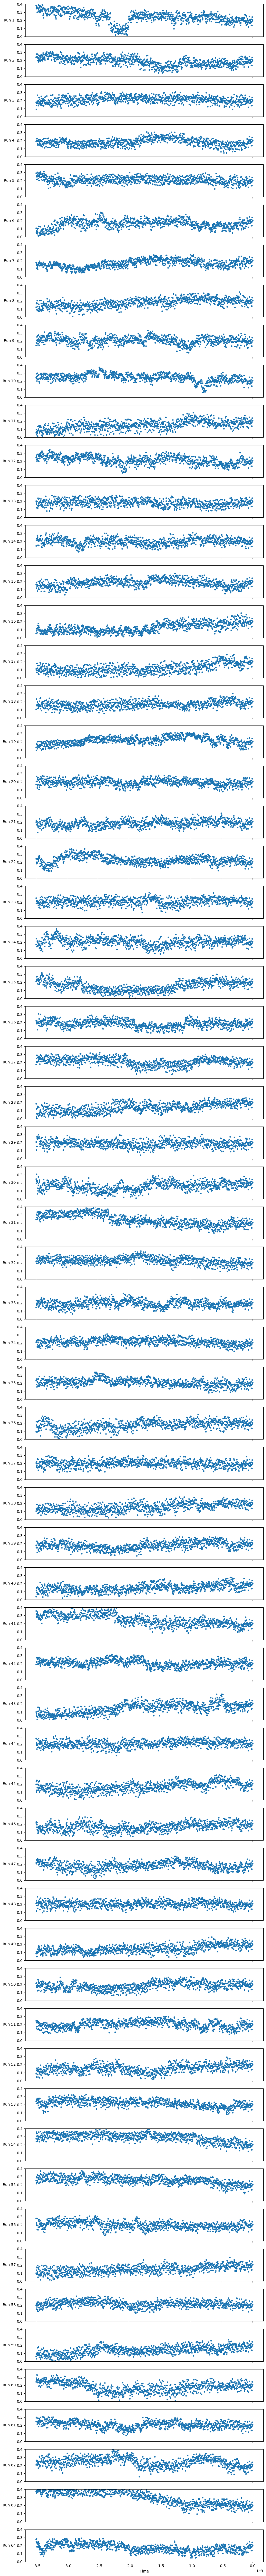

In [209]:
n_runs = len(ls)
fig, axes = plt.subplots(nrows=n_runs, ncols=1, figsize=(10, n_runs*1.5), sharex=True)

for idx, ax in enumerate(axes):
    theta_i = es[(idx)]
    ax.plot(times_i, theta_i,'.')
    ax.set_ylim(0, 0.4)
    ax.set_ylabel(f'Run {idx + 1}', rotation=0, labelpad=20, va='center')

axes[-1].set_xlabel('Time')

plt.tight_layout()
plt.savefig('resonance.png')
plt.show()

Run 63.
